# **Machine Learning Project**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
import re
import warnings
warnings.filterwarnings('ignore')

## Part 0: DATA DESCRIPTION


In [3]:
data = pd.read_csv("train.csv", engine="python", encoding='latin1',on_bad_lines='skip')
data.head(10)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
5,00025465d4725e87,"""\n\nCongratulations from me as well, use the ...",0,0,0,0,0,0
6,0002bcb3da6cb337,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0
7,00031b1e95af7921,Your vandalism to the Matt Shirvington article...,0,0,0,0,0,0
8,00037261f536c51d,Sorry if the word 'nonsense' was offensive to ...,0,0,0,0,0,0
9,00040093b2687caa,alignment on this subject and which are contra...,0,0,0,0,0,0


In [4]:
print("=== EXPLORATION DES DONNÉES ===")
print(f"Shape du dataset: {data.shape}")
print(f"Colonnes: {data.columns.tolist()}")
print(f"\nValeurs manquantes:")
print(data.isnull().sum())

=== EXPLORATION DES DONNÉES ===
Shape du dataset: (159571, 8)
Colonnes: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Valeurs manquantes:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


In [5]:
# Distribution de la variable cible 'toxic'
print(f"\n=== DISTRIBUTION DE LA VARIABLE TOXIC ===")
print(data['toxic'].value_counts())
toxic_percent = data['toxic'].mean() * 100
print(f"Pourcentage de commentaires toxiques: {toxic_percent:.2f}%")


=== DISTRIBUTION DE LA VARIABLE TOXIC ===
toxic
0    144277
1     15294
Name: count, dtype: int64
Pourcentage de commentaires toxiques: 9.58%


Text(0, 0.5, 'Nombre de commentaires')

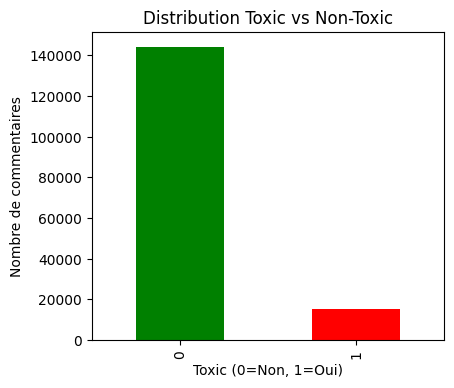

In [6]:
# Visualisation de la distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
data['toxic'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution Toxic vs Non-Toxic')
plt.xlabel('Toxic (0=Non, 1=Oui)')
plt.ylabel('Nombre de commentaires')

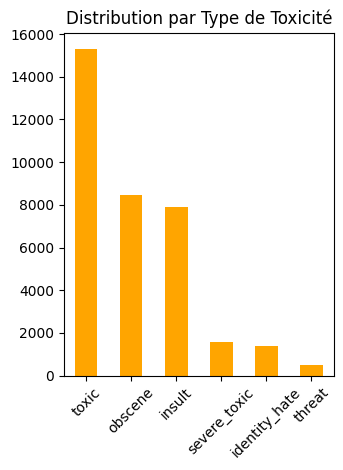

In [7]:
# Distribution de toutes les catégories
plt.subplot(1, 2, 2)
toxic_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
toxic_counts = data[toxic_cols].sum().sort_values(ascending=False)
toxic_counts.plot(kind='bar', color='orange')
plt.title('Distribution par Type de Toxicité')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## PART 1: TEXT PREPROCESSING

In [8]:
## Prise en compte de caractères spéciaux
def count_upper_case_percentage(text):
    """Calcule le pourcentage de lettres majuscules."""
    if pd.isna(text) or not text:
        return 0
    upper_count = sum(1 for char in text if char.isupper())
    total_chars = len(text)
    return upper_count / total_chars

def count_punctuation_percentage(text, punctuation):
    """Calcule le pourcentage d'un type de ponctuation."""
    if pd.isna(text) or not text:
        return 0
    punc_count = text.count(punctuation)
    total_chars = len(text)
    return punc_count / total_chars

# Créer les colonnes de pourcentages
data['upper_case_percentage'] = data['comment_text'].apply(count_upper_case_percentage)
data['exclamation_percentage'] = data['comment_text'].apply(lambda x: count_punctuation_percentage(str(x), '!'))
data['question_mark_percentage'] = data['comment_text'].apply(lambda x: count_punctuation_percentage(str(x), '?'))
data['quotation_mark_percentage'] = data['comment_text'].apply(lambda x: count_punctuation_percentage(str(x), '"'))

# Fonction de nettoyage de texte améliorée
def clean_text_for_tokens(text):
    """Nettoie le texte pour la tokenisation."""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    # Supprime les caractères spéciaux à l'exception des ponctuations qui ont déjà été comptées
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Appliquer la fonction de nettoyage sur une nouvelle colonne
data['cleaned_text'] = data['comment_text'].apply(clean_text_for_tokens)

# Afficher les nouvelles colonnes
print(data[['comment_text', 'upper_case_percentage', 'exclamation_percentage', 'question_mark_percentage', 'quotation_mark_percentage', 'cleaned_text']].head())

                                        comment_text  upper_case_percentage  \
0  Explanation\nWhy the edits made under my usern...               0.064394   
1  D'aww! He matches this background colour I'm s...               0.071429   
2  Hey man, I'm really not trying to edit war. It...               0.017167   
3  "\nMore\nI can't make any real suggestions on ...               0.017685   
4  You, sir, are my hero. Any chance you remember...               0.029851   

   exclamation_percentage  question_mark_percentage  \
0                0.000000                  0.003788   
1                0.008929                  0.000000   
2                0.000000                  0.000000   
3                0.000000                  0.000000   
4                0.000000                  0.014925   

   quotation_mark_percentage  \
0                   0.000000   
1                   0.000000   
2                   0.000000   
3                   0.009646   
4                   0.000000   

 

In [9]:
# Crée les colonnes pour la longueur du texte et le nombre de mots
data['comment_length'] = data['cleaned_text'].str.len()
data['word_count'] = data['cleaned_text'].str.split().str.len()

# Affiche les statistiques descriptives pour toutes les variables
print("### Statistiques Descriptives par Classe de Toxicité ###")

# Analyse du pourcentage de majuscules
print("\n--- Pourcentage de Majuscules ---")
print(data.groupby('toxic')['upper_case_percentage'].describe())

# Analyse du pourcentage de points d'exclamation
print("\n--- Pourcentage de Points d'Exclamation ---")
print(data.groupby('toxic')['exclamation_percentage'].describe())

# Analyse du pourcentage de points d'interrogation
print("\n--- Pourcentage de Points d'Interrogation ---")
print(data.groupby('toxic')['question_mark_percentage'].describe())

# Analyse du pourcentage de guillemets
print("\n--- Pourcentage de Guillemets ---")
print(data.groupby('toxic')['quotation_mark_percentage'].describe())

# Analyse de la longueur des commentaires
print("\n--- Longueur des Commentaires ---")
print(data.groupby('toxic')['comment_length'].describe())

# Analyse du nombre de mots
print("\n--- Nombre de Mots ---")
print(data.groupby('toxic')['word_count'].describe())

### Statistiques Descriptives par Classe de Toxicité ###

--- Pourcentage de Majuscules ---
          count      mean       std  min       25%       50%       75%  \
toxic                                                                    
0      144277.0  0.045399  0.065832  0.0  0.020983  0.031915  0.048387   
1       15294.0  0.114717  0.211602  0.0  0.019417  0.035191  0.070423   

            max  
toxic            
0      0.962963  
1      0.998189  

--- Pourcentage de Points d'Exclamation ---
          count      mean       std  min  25%  50%      75%       max
toxic                                                                
0      144277.0  0.001549  0.011985  0.0  0.0  0.0  0.00000  0.900000
1       15294.0  0.009252  0.040777  0.0  0.0  0.0  0.00202  0.994366

--- Pourcentage de Points d'Interrogation ---
          count      mean       std  min  25%  50%       75%       max
toxic                                                                 
0      144277.0  0.002043

In [10]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

# 1. Télécharger les ressources NLTK nécessaires pour la lemmatisation et le taggage
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

# 2. Initialiser le lemmatiseur
lemmatizer = WordNetLemmatizer()

# --- Étape 1 : Tokenisation ---
# La mise en minuscules et le nettoyage sont déjà faits dans 'cleaned_text',
# nous n'avons plus qu'à tokeniser cette colonne.
data['tokens'] = data['cleaned_text'].apply(lambda x: word_tokenize(x))

# --- Étape 2 : Suppression des mots vides (Stopwords) ---
# Définit l'ensemble des mots vides et retire ceux que vous voulez garder.
stop_words = set(stopwords.words('english'))
stop_words -= {"not", "no", "nor", "n't", "you", "your", "yours", "me", "my", "mine", "we", "us"}

# Applique la suppression des mots vides à la colonne 'tokens'
data['tokens_nostop'] = data['tokens'].apply(
    lambda toks: [t for t in toks if t not in stop_words]
)

# --- Étape 3 : Lemmatisation ---
# Fonction pour obtenir le tag WordNet (nécessaire pour la lemmatisation)
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

# Applique la lemmatisation sur les tokens sans mots vides
def lemmatize_tokens(tokens):
    # Taggage grammatical des mots
    tagged_tokens = nltk.pos_tag(tokens)
    lemmatized_list = []
    for token, tag in tagged_tokens:
        wordnet_tag = get_wordnet_pos(tag)
        lemmatized_list.append(lemmatizer.lemmatize(token, wordnet_tag))
    return lemmatized_list

data['tokens_lemmatized'] = data['tokens_nostop'].apply(lemmatize_tokens)

# Affiche un aperçu des colonnes finales
print(data[['cleaned_text', 'tokens_nostop', 'tokens_lemmatized']].head())

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


                                        cleaned_text  \
0  explanation why the edits made under my userna...   
1  d aww he matches this background colour i m se...   
2  hey man i m really not trying to edit war it s...   
3  more i can t make any real suggestions on impr...   
4  you sir are my hero any chance you remember wh...   

                                       tokens_nostop  \
0  [explanation, edits, made, my, username, hardc...   
1  [aww, matches, background, colour, seemingly, ...   
2  [hey, man, really, not, trying, edit, war, guy...   
3  [make, real, suggestions, improvement, wondere...   
4  [you, sir, my, hero, chance, you, remember, page]   

                                   tokens_lemmatized  
0  [explanation, edits, make, my, username, hardc...  
1  [aww, match, background, colour, seemingly, st...  
2  [hey, man, really, not, try, edit, war, guy, c...  
3  [make, real, suggestion, improvement, wonder, ...  
4  [you, sir, my, hero, chance, you, remember, page

## PART 2: FEATURE ENGINEERING

In [11]:
# Joindre les tokens lemmatisés en une seule chaîne
data['processed_text_lemmatized'] = data['tokens_lemmatized'].apply(lambda toks: " ".join(toks))

# Ensuite, importer la librairie pour la vectorisation
from sklearn.feature_extraction.text import CountVectorizer

# --- Représentation 1 : Unigrams (mots individuels) ---
# Ceci est le Bag-of-Words standard.
vectorizer_unigram = CountVectorizer(ngram_range=(1, 1))
X_unigram = vectorizer_unigram.fit_transform(data['processed_text_lemmatized'])
print("Dimensions de la matrice BoW (Unigrams) :", X_unigram.shape)

# --- Représentation 2 : Unigrams + Bigrams (mots individuels + paires de mots) ---
# Ceci est une représentation plus riche.
vectorizer_bigram = CountVectorizer(ngram_range=(1, 2))
X_bigram = vectorizer_bigram.fit_transform(data['processed_text_lemmatized'])
print("Dimensions de la matrice (Bigrams) :", X_bigram.shape)

Dimensions de la matrice BoW (Unigrams) : (159571, 171497)
Dimensions de la matrice (Bigrams) : (159571, 2552836)


Préparation de données

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# On suppose que 'data' est ton DataFrame et que les colonnes suivantes existent :
# 'processed_text_lemmatized'
# 'upper_case_percentage', 'exclamation_percentage', 'question_mark_percentage', 'quotation_mark_percentage'

# Définition des caractéristiques (X) et des cibles (y)
X_text = data['processed_text_lemmatized']
X_features = data[['upper_case_percentage', 'exclamation_percentage', 'comment_length', 'word_count']]
y = data['toxic']

# Séparation des données en ensembles d'entraînement et de test
X_text_train, X_text_test, X_features_train, X_features_test, y_train, y_test = train_test_split(
    X_text, X_features, y, test_size=0.2, random_state=42, stratify=y
)

# Vectorisation du texte
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_text_train)
X_test_tfidf = tfidf_vectorizer.transform(X_text_test)

# Fusion des matrices de caractéristiques
X_train_combined = hstack([X_train_tfidf, X_features_train.values])
X_test_combined = hstack([X_test_tfidf, X_features_test.values])

## PART 3: Modeling

 Logistic Regression

In [13]:
# --- Régression Logistique ---
clf_lr = LogisticRegression(solver='liblinear', random_state=42)
clf_lr.fit(X_train_combined, y_train)
y_pred_test_lr = clf_lr.predict(X_test_combined)



SVM Regression

In [14]:
# --- SVM Linéaire ---
clf_svm = LinearSVC(random_state=42)
clf_svm.fit(X_train_combined, y_train)
y_pred_test_svm = clf_svm.predict(X_test_combined)


Random Forest Regression

In [15]:
# --- Random Forest Classifier ---
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_train_combined, y_train)
y_pred_test_rf = clf_rf.predict(X_test_combined)

# PART 4: EVALUATION

In [16]:
from sklearn.metrics import accuracy_score, classification_report

# --- Évaluation de la Régression Logistique ---
print("--- Évaluation : Régression Logistique (avec caractéristiques combinées) ---")
print(f"Précision (Accuracy) : {accuracy_score(y_test, y_pred_test_lr):.4f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_test_lr, zero_division=0))

# Matrice de confusion
cm_kw = confusion_matrix(y_test, y_pred_test_lr)
pd.DataFrame(cm_kw,
             index=["non-toxic","toxic"],
             columns=["pred_non-toxic","pred_toxic"])

--- Évaluation : Régression Logistique (avec caractéristiques combinées) ---
Précision (Accuracy) : 0.9587

Rapport de classification :
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     28856
           1       0.91      0.63      0.75      3059

    accuracy                           0.96     31915
   macro avg       0.94      0.81      0.86     31915
weighted avg       0.96      0.96      0.96     31915



,pred_non-toxic,pred_toxic
non-toxic,28664,192
toxic,1126,1933


In [17]:
# --- Évaluation du SVM Linéaire ---
print("\n--- Évaluation : SVM Linéaire (avec caractéristiques combinées) ---")
print(f"Précision (Accuracy) : {accuracy_score(y_test, y_pred_test_svm):.4f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_test_svm, zero_division=0))

# Matrice de confusion
cm_kw = confusion_matrix(y_test, y_pred_test_svm)
pd.DataFrame(cm_kw,
             index=["non-toxic","toxic"],
             columns=["pred_non-toxic","pred_toxic"])


--- Évaluation : SVM Linéaire (avec caractéristiques combinées) ---
Précision (Accuracy) : 0.8401

Rapport de classification :
              precision    recall  f1-score   support

           0       0.97      0.85      0.91     28856
           1       0.35      0.78      0.48      3059

    accuracy                           0.84     31915
   macro avg       0.66      0.81      0.69     31915
weighted avg       0.91      0.84      0.86     31915



,pred_non-toxic,pred_toxic
non-toxic,24424,4432
toxic,670,2389


In [18]:
# --- Évaluation du Random Forest ---
print("\n--- Évaluation : Random Forest (avec caractéristiques combinées) ---")
print(f"Précision (Accuracy) : {accuracy_score(y_test, y_pred_test_rf):.4f}")
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_test_rf, zero_division=0))

# Matrice de confusion
cm_kw = confusion_matrix(y_test, y_pred_test_rf)
pd.DataFrame(cm_kw,
             index=["non-toxic","toxic"],
             columns=["pred_non-toxic","pred_toxic"])


--- Évaluation : Random Forest (avec caractéristiques combinées) ---
Précision (Accuracy) : 0.9492

Rapport de classification :
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     28856
           1       0.97      0.49      0.65      3059

    accuracy                           0.95     31915
   macro avg       0.96      0.74      0.81     31915
weighted avg       0.95      0.95      0.94     31915



,pred_non-toxic,pred_toxic
non-toxic,28805,51
toxic,1569,1490


# Part 5: Calcul of AUC

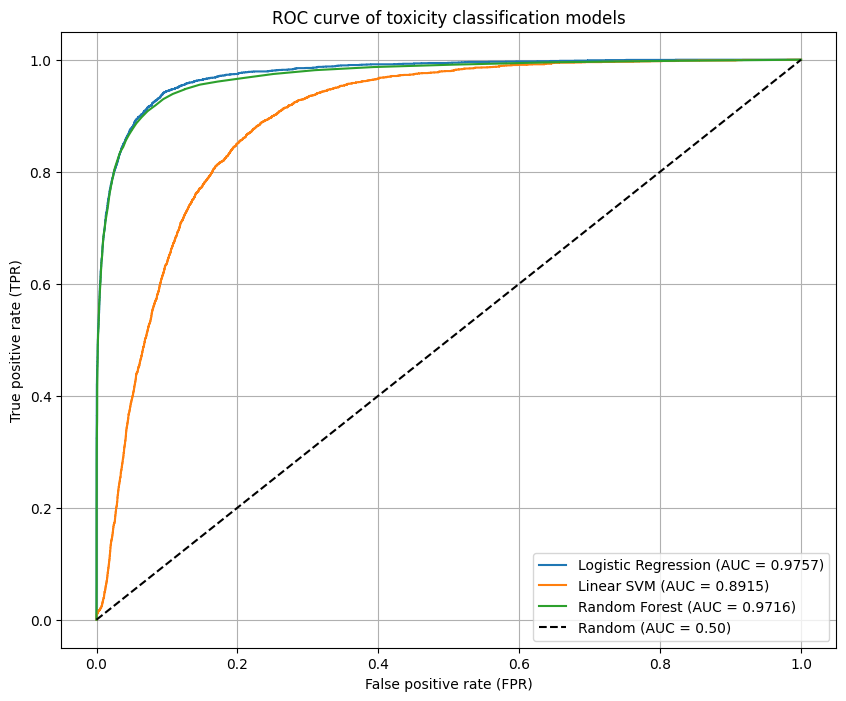

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# --- Régression Logistique ---
# Pour l'AUC, nous avons besoin des probabilités pour la classe 1
y_pred_proba_lr = clf_lr.predict_proba(X_test_combined)[:, 1]
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)

# --- SVM Linéaire ---
# LinearSVC n'a pas de méthode predict_proba, on utilise decision_function
y_pred_proba_svm = clf_svm.decision_function(X_test_combined)
auc_svm = roc_auc_score(y_test, y_pred_proba_svm)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_proba_svm)

# --- Random Forest ---
y_pred_proba_rf = clf_rf.predict_proba(X_test_combined)[:, 1]
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)


# --- Tracé de la courbe ROC ---
plt.figure(figsize=(10, 8))

# Tracé pour la Régression Logistique
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')

# Tracé pour le SVM Linéaire
plt.plot(fpr_svm, tpr_svm, label=f'Linear SVM (AUC = {auc_svm:.4f})')

# Tracé pour le Random Forest
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')

# Tracé de la ligne de base (prédiction aléatoire)
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')

plt.xlabel('False positive rate (FPR)')
plt.ylabel('True positive rate (TPR)')
plt.title('ROC curve of toxicity classification models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Modeling with baseline

In [20]:
# Minimal keyword baseline
TOXIC = {
    "idiot", "stupid", "dumb", "loser", "moron", "sucker", "asshole", "bitch", "bastard", "prick", "dick", "pussy", "cunt", "jerk",
    "retard", "fuck", "fucking", "fucker", "shit", "bullshit", "piss", "crap", "hell", "damn", "whore", "slut", "motherfucker", "gay",
    "faggot", "homo", "queer", "lesbo", "tranny", "nigger", "negro", "chink", "jap", "muslim", "jew", "nazi", "hitler", "terrorist",
    "kill", "die", "death", "bomb", "rape", "attack", "destroy", "shoot", "stab", "hang","horrible","nigger","you","idiot",
    "moron","hate","shit","bullshit","faggot","wanker","jew", "stupid","bark","racist","fuck", "fucking", "shit", "idiot", "moron", "stupid", "asshole", "bitch",
    "nigger", "fag", "faggot", "jew", "pig", "trash", "kill", "die", "dumb"
}

In [21]:
X_text = data['processed_text_lemmatized']
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.20, random_state=42, stratify=y
)

In [22]:
def keyword_rule_toxic(text: str) -> int:
    toks = text.lower().split()
    toxic_hits = sum(1 for w in toks if w in TOXIC)
    return int(toxic_hits > 0)  # 1 si toxique, 0 sinon

    # Predictions baseline
y_pred_train_keyword = [keyword_rule_toxic(t) for t in X_train_text]
y_pred_test_keyword  = [keyword_rule_toxic(t) for t in X_test_text]

Evaluation with baseline

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

print("Logistic - Keyword baseline — classification report")
print(classification_report(y_test, y_pred_test_keyword, target_names=["non-toxic","toxic"]))

# Matrice de confusion
cm_kw = confusion_matrix(y_test, y_pred_test_keyword)
pd.DataFrame(cm_kw,
             index=["non-toxic","toxic"],
             columns=["pred_non-toxic","pred_toxic"])

Logistic - Keyword baseline — classification report
              precision    recall  f1-score   support

   non-toxic       0.97      0.50      0.66     28856
       toxic       0.16      0.87      0.26      3059

    accuracy                           0.54     31915
   macro avg       0.56      0.69      0.46     31915
weighted avg       0.89      0.54      0.62     31915



,pred_non-toxic,pred_toxic
non-toxic,14505,14351
toxic,404,2655
